# JOB 3 — Baseline Model: Historical Affinity

**Goal:** Build and evaluate a time-decayed affinity baseline for Eurovision jury vote prediction.

**Pipeline:**
1. Load & inspect data
2. Run rolling backtest
3. Compare `half_life` values
4. Per-jury error analysis
5. Save best predictions

## 0 — Imports & path setup

In [1]:
import sys
from pathlib import Path

# Make sure src/ is on the path so we can import eurojury and models
repo_root = Path(".").resolve().parents[0]  # adjust if notebook is nested deeper
sys.path.insert(0, str(repo_root / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from eurojury.aggregate import load
from models.baseline import rolling_backtest, predict_year
from models.metrics import evaluate

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.3f}".format)

## 1 — Load & inspect data

In [2]:
df = load()  # loads all available years, runs validate_all() internally

print(f"Shape		 : {df.shape}")
print(f"Years		 : {sorted(df['year'].unique())}")
print(f"Unique juries: {df['jury_iso'].nunique()}")
print()
df.head(10)

Shape		 : (8999, 6)
Years		 : [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Unique juries: 45



,performer_country,jury_country,jury_points,year,performer_iso,jury_iso
0,Belgium,Austria,5,2016,BEL,AUT
1,Czech Republic,Austria,4,2016,CZE,AUT
2,Netherlands,Austria,0,2016,NLD,AUT
3,Azerbaijan,Austria,0,2016,AZE,AUT
4,Hungary,Austria,0,2016,HUN,AUT
5,Italy,Austria,0,2016,ITA,AUT
6,Israel,Austria,0,2016,ISR,AUT
7,Bulgaria,Austria,0,2016,BGR,AUT
8,Sweden,Austria,8,2016,SWE,AUT
9,Germany,Austria,0,2016,DEU,AUT


In [3]:
# Juries and performers per year — quick sanity check
summary = (
	df.groupby("year")
	.agg(
		n_juries=("jury_iso", "nunique"),
		n_performers=("performer_iso", "nunique"),
		total_rows=("jury_points", "count"),
	)
)
summary

,n_juries,n_performers,total_rows
year,,,
2016,42,26,1066
2017,42,26,1066
2018,43,26,1092
2019,41,26,1040
2021,39,26,988
2022,40,25,975
2023,37,26,936
2024,37,25,900
2025,37,26,936


## 2 — Rolling backtest (default half_life=3)

In [4]:
print("Running rolling backtest (half_life=3, min_train_years=4)...\n")
predictions, results = rolling_backtest(df, half_life=3.0)

print("\n--- Results per year ---")
results

Running rolling backtest (half_life=3, min_train_years=4)...

  Skipping 2016 — only 0 training year(s).
  Skipping 2017 — only 1 training year(s).
  Skipping 2018 — only 2 training year(s).
  Skipping 2019 — only 3 training year(s).
  2021 | nDCG@10=0.470 | Spearman=0.173 | Top3-HR=0.564 | juries=39
  2022 | nDCG@10=0.402 | Spearman=0.108 | Top3-HR=0.425 | juries=40
  2023 | nDCG@10=0.513 | Spearman=0.249 | Top3-HR=0.649 | juries=37
  2024 | nDCG@10=0.460 | Spearman=0.179 | Top3-HR=0.514 | juries=37
  2025 | nDCG@10=0.506 | Spearman=0.269 | Top3-HR=0.676 | juries=37

--- Results per year ---


,ndcg@10,spearman,top3_hit_rate,n_juries,n_train_years
year,,,,,
2021,0.470,0.173,0.564,39,4
2022,0.402,0.108,0.425,40,5
2023,0.513,0.249,0.649,37,6
2024,0.460,0.179,0.514,37,7
2025,0.506,0.269,0.676,37,8


> **nDCG@10=0.470, Top-3 HR=0.564** — meaningful signal above a random baseline (~0.33). 2022 is the weakest year; 2023–2025 show a recovery.

In [5]:
print("--- Macro average across all test years ---")
results[["ndcg@10", "spearman", "top3_hit_rate"]].mean().to_frame("mean")

--- Macro average across all test years ---


,mean
ndcg@10,0.470
spearman,0.196
top3_hit_rate,0.565


> **Macro ortalama:** nDCG@10=0.470 | Spearman=0.196 | Top-3 HR=0.565 — Spearman is low; sparse vote distribution suppresses lower-rank correlation.

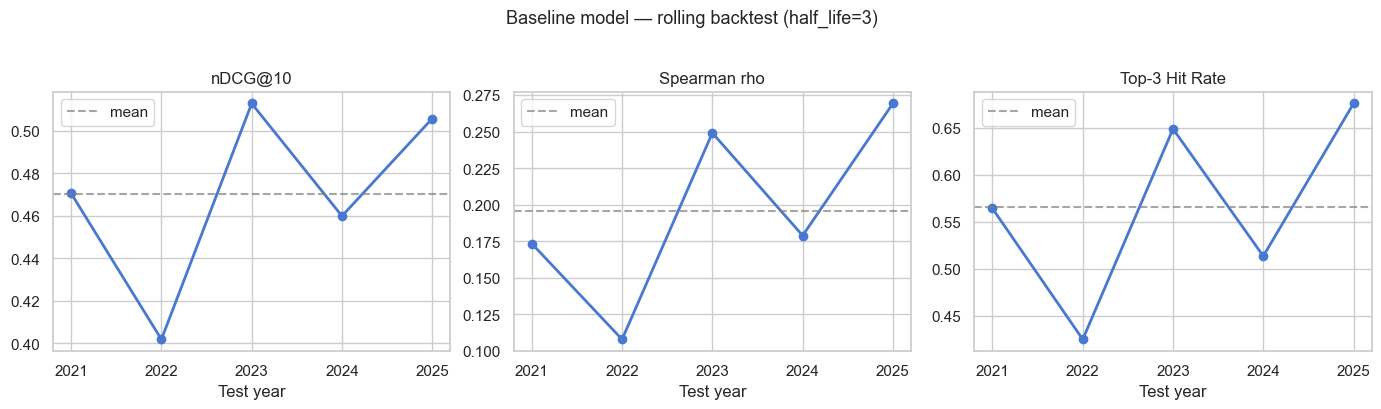

In [6]:
# Plot metrics over years
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

metric_labels = {
	"ndcg@10": "nDCG@10",
	"spearman": "Spearman rho",
	"top3_hit_rate": "Top-3 Hit Rate",
}

for ax, (col, label) in zip(axes, metric_labels.items()):
	ax.plot(results.index, results[col], marker="o", linewidth=2)
	ax.axhline(results[col].mean(), linestyle="--", color="gray", alpha=0.7, label="mean")
	ax.set_title(label)
	ax.set_xlabel("Test year")
	ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
	ax.legend()

plt.suptitle("Baseline model — rolling backtest (half_life=3)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> All three metrics dip in 2022 — likely driven by politically motivated voting toward Ukraine, an anomaly the historical affinity model cannot capture.

## 3 — Half-life sensitivity analysis

How sensitive are results to the decay parameter?
We test `half_life ∈ {1, 2, 3, 5, 10}` where:
- **1** = very aggressive decay, almost only last year matters
- **10** = very slow decay, all years weighted nearly equally

In [7]:
half_lives = [1, 2, 3, 5, 10]
hl_results = {}

for hl in half_lives:
	print(f"half_life={hl}")
	_, res = rolling_backtest(df, half_life=hl)
	hl_results[hl] = res[["ndcg@10", "spearman", "top3_hit_rate"]].mean()
	print()

hl_df = pd.DataFrame(hl_results).T
hl_df.index.name = "half_life"
hl_df

half_life=1
  Skipping 2016 — only 0 training year(s).
  Skipping 2017 — only 1 training year(s).
  Skipping 2018 — only 2 training year(s).
  Skipping 2019 — only 3 training year(s).
  2021 | nDCG@10=0.453 | Spearman=0.166 | Top3-HR=0.538 | juries=39
  2022 | nDCG@10=0.371 | Spearman=0.080 | Top3-HR=0.375 | juries=40
  2023 | nDCG@10=0.457 | Spearman=0.213 | Top3-HR=0.541 | juries=37
  2024 | nDCG@10=0.429 | Spearman=0.135 | Top3-HR=0.486 | juries=37
  2025 | nDCG@10=0.473 | Spearman=0.239 | Top3-HR=0.649 | juries=37

half_life=2
  Skipping 2016 — only 0 training year(s).
  Skipping 2017 — only 1 training year(s).
  Skipping 2018 — only 2 training year(s).
  Skipping 2019 — only 3 training year(s).
  2021 | nDCG@10=0.466 | Spearman=0.171 | Top3-HR=0.590 | juries=39
  2022 | nDCG@10=0.394 | Spearman=0.105 | Top3-HR=0.375 | juries=40
  2023 | nDCG@10=0.482 | Spearman=0.232 | Top3-HR=0.649 | juries=37
  2024 | nDCG@10=0.462 | Spearman=0.167 | Top3-HR=0.541 | juries=37
  2025 | nDCG@10=0.

,ndcg@10,spearman,top3_hit_rate
half_life,,,
1,0.437,0.167,0.518
2,0.460,0.187,0.571
3,0.470,0.196,0.565
5,0.476,0.204,0.560
10,0.478,0.210,0.560


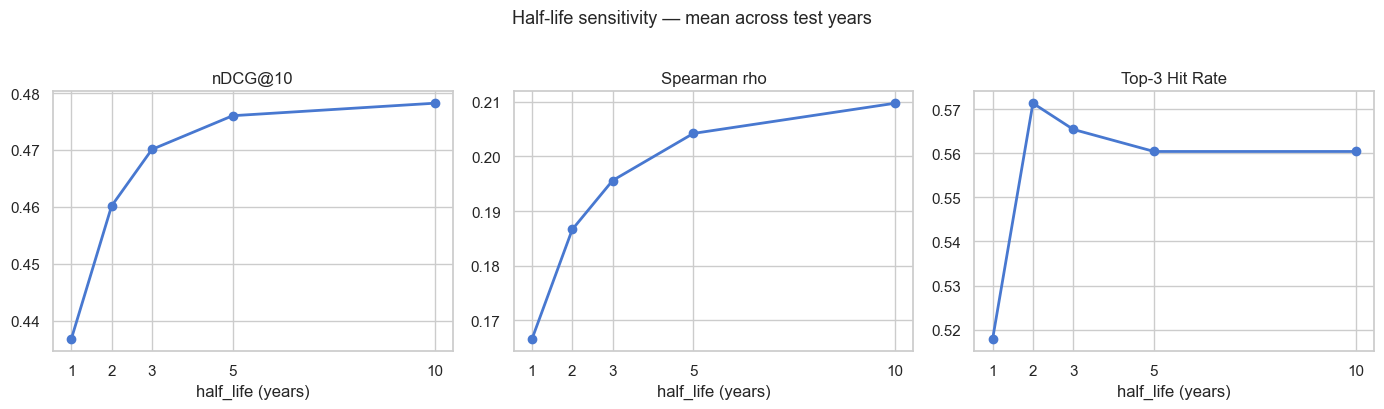

Best half_life by nDCG@10: 10


In [8]:
# Plot half-life sensitivity
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, label) in zip(axes, metric_labels.items()):
	ax.plot(hl_df.index, hl_df[col], marker="o", linewidth=2)
	ax.set_title(label)
	ax.set_xlabel("half_life (years)")
	ax.set_xticks(half_lives)

plt.suptitle("Half-life sensitivity — mean across test years", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

best_hl = hl_df["ndcg@10"].idxmax()
print(f"Best half_life by nDCG@10: {best_hl}")

> The nDCG@10 curve flattens beyond half_life=5, suggesting diminishing returns from weighting older years more equally.

## 4 — Per-jury error analysis

Which juries does the model struggle with most?
This helps us understand where historical affinity is a weak signal.

In [9]:
# Re-run backtest with best half_life for per-jury analysis
best_predictions, best_results = rolling_backtest(df, half_life=best_hl)

# Compute per-jury nDCG@10 across all test years
jury_scores = []

for (year, jury), group in best_predictions.groupby(["year", "jury_iso"]):
	metrics = evaluate(group)
	jury_scores.append({
		"year": year,
		"jury_iso": jury,
		"ndcg@10": metrics["ndcg@10"],
		"spearman": metrics["spearman"],
		"top3_hit_rate": metrics["top3_hit_rate"],
	})

jury_df = pd.DataFrame(jury_scores)
jury_df.head()

  Skipping 2016 — only 0 training year(s).
  Skipping 2017 — only 1 training year(s).
  Skipping 2018 — only 2 training year(s).
  Skipping 2019 — only 3 training year(s).
  2021 | nDCG@10=0.460 | Spearman=0.167 | Top3-HR=0.564 | juries=39
  2022 | nDCG@10=0.406 | Spearman=0.125 | Top3-HR=0.400 | juries=40
  2023 | nDCG@10=0.523 | Spearman=0.261 | Top3-HR=0.649 | juries=37
  2024 | nDCG@10=0.480 | Spearman=0.205 | Top3-HR=0.595 | juries=37
  2025 | nDCG@10=0.522 | Spearman=0.289 | Top3-HR=0.595 | juries=37


,year,jury_iso,ndcg@10,spearman,top3_hit_rate
0,2021,ALB,0.681,0.344,1.000
1,2021,AUS,0.341,-0.122,1.000
2,2021,AUT,0.605,0.425,1.000
3,2021,AZE,0.793,0.486,1.000
4,2021,BEL,0.485,0.178,1.000


In [10]:
# Average per jury across all test years
jury_avg = (
	jury_df.groupby("jury_iso")[["ndcg@10", "spearman", "top3_hit_rate"]]
	.mean()
	.sort_values("ndcg@10")
)

print("--- Bottom 10 juries (hardest to predict) ---")
print(jury_avg.head(10))
print()
print("--- Top 10 juries (easiest to predict) ---")
print(jury_avg.tail(10))

--- Bottom 10 juries (hardest to predict) ---
          ndcg@10  spearman  top3_hit_rate
jury_iso                                  
ROU         0.287     0.011          0.000
BGR         0.324    -0.033          0.500
ITA         0.329     0.015          0.200
SRB         0.370     0.070          0.200
FRA         0.395     0.207          0.400
PRT         0.399     0.136          0.200
UKR         0.401     0.188          0.400
AZE         0.403     0.221          0.400
MKD         0.409     0.142          0.500
AUS         0.410     0.078          0.800

--- Top 10 juries (easiest to predict) ---
          ndcg@10  spearman  top3_hit_rate
jury_iso                                  
ISL         0.521     0.337          0.400
GEO         0.539     0.326          0.600
NLD         0.555     0.226          0.800
ARM         0.566     0.336          0.750
MDA         0.567     0.301          0.500
ALB         0.582     0.285          0.800
EST         0.615     0.342          0.800
FIN    

> **Hardest to predict:** ROU, BGR, ITA — inconsistent or volatile voting patterns. **Easiest to predict:** EST, CYP, FIN — strong and stable bilateral relationships.

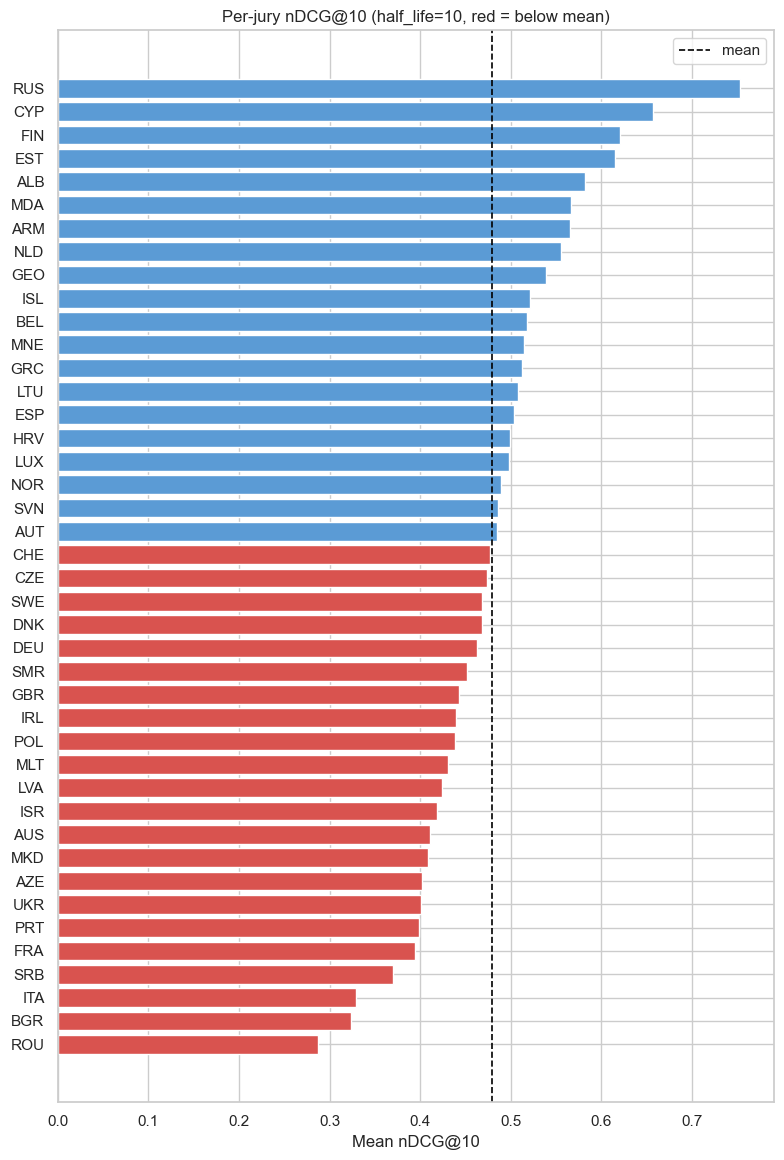

In [11]:
# Horizontal bar chart — nDCG@10 per jury
fig, ax = plt.subplots(figsize=(8, max(6, len(jury_avg) * 0.28)))

colors = ["#d9534f" if v < jury_avg["ndcg@10"].mean() else "#5b9bd5"
		  for v in jury_avg["ndcg@10"]]

ax.barh(jury_avg.index, jury_avg["ndcg@10"], color=colors)
ax.axvline(jury_avg["ndcg@10"].mean(), color="black",
		   linestyle="--", linewidth=1.2, label="mean")
ax.set_xlabel("Mean nDCG@10")
ax.set_title(f"Per-jury nDCG@10 (half_life={best_hl}, red = below mean)")
ax.legend()
plt.tight_layout()
plt.show()

> Red bars are concentrated among Balkan and Western European juries — regions with less predictable bilateral voting patterns.

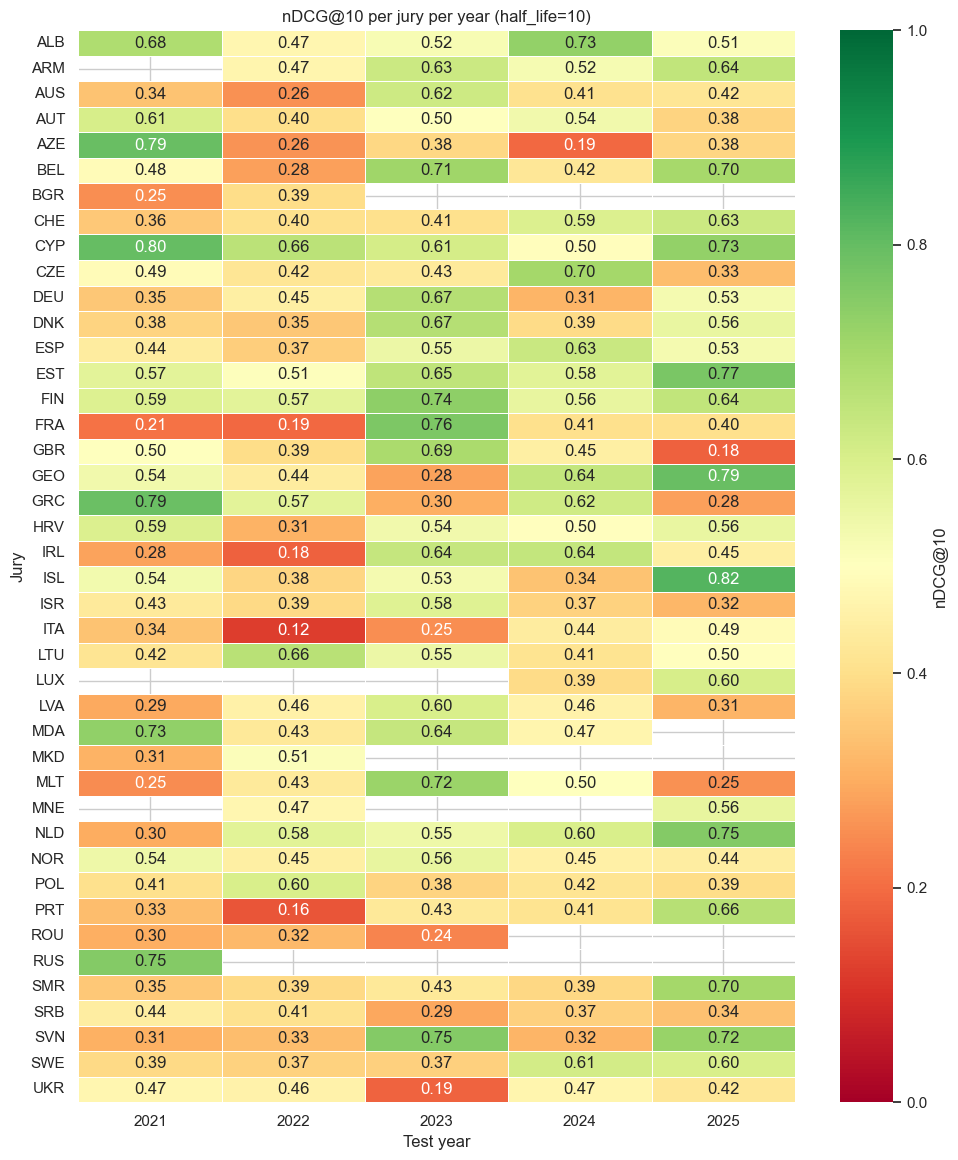

In [12]:
# Heatmap: jury × year nDCG@10
pivot = jury_df.pivot(index="jury_iso", columns="year", values="ndcg@10")

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.28)))
sns.heatmap(
	pivot,
	ax=ax,
	cmap="RdYlGn",
	vmin=0, vmax=1,
	linewidths=0.4,
	annot=True,
	fmt=".2f",
	cbar_kws={"label": "nDCG@10"},
)
ax.set_title(f"nDCG@10 per jury per year (half_life={best_hl})")
ax.set_xlabel("Test year")
ax.set_ylabel("Jury")
plt.tight_layout()
plt.show()

> CYP and FIN show consistently high nDCG@10 across all test years, confirming stable long-term preferences.

## 5 — Save best predictions

In [13]:
output_path = repo_root / "data" / "processed" / "job3_baseline_predictions.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

best_predictions.to_csv(output_path, index=False)
print(f"Saved {len(best_predictions)} rows → {output_path}")
best_predictions.head()

Saved 4735 rows → /Users/meryemyaren/GitHub/eurovision-vote-forecast/data/processed/job3_baseline_predictions.csv


,year,jury_iso,performer_iso,jury_points,predicted_score,predicted_points
0,2021,ISR,CYP,3,0.000,0
1,2021,ISR,ALB,0,0.000,0
2,2021,ISR,BEL,6,7.035,12
3,2021,ISR,RUS,7,0.000,0
4,2021,ISR,MLT,5,2.207,0
